# Does the grid decide the race? F1, 1950 to 2026

**Question:** How well does starting grid position predict finishing position, and has that changed across eras?

This notebook follows `analysis_plan.md` step by step. Each section ends with a **checkpoint** that prints numbers to verify before moving on.

**Data:** [Arths17/f1-dataset](https://github.com/Arths17/f1-dataset) (CC0). The 4 CSVs used here are in the `data/` folder next to this notebook. Requires `pandas` and `matplotlib`.

## 1. Load and merge

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("data")   # CSVs ship next to this notebook
NA = "\\N"                          # the dataset writes missing values as the text \N

results = pd.read_csv(DATA / "results.csv", na_values=NA)
races   = pd.read_csv(DATA / "races.csv",   na_values=NA)
status  = pd.read_csv(DATA / "status.csv")

df = (results
      .merge(races[["raceId", "year", "round", "name"]], on="raceId", how="left")
      .merge(status, on="statusId", how="left"))
df["decade"] = df["year"] // 10 * 10

In [2]:
# Checkpoint 1: merges should not add or lose rows, and every row should find its race and status
print("results rows:", len(results), "| merged rows:", len(df))
print("unmatched race or status:", df[["year", "status"]].isna().any(axis=1).sum())
print("seasons:", df["year"].min(), "to", df["year"].max())
last = races.loc[races["date"].idxmax()]
print("latest race in data:", last["name"], last["date"])

results rows: 27590 | merged rows: 27590
unmatched race or status: 0
seasons: 1950 to 2026
latest race in data: Bahrain Grand Prix in Malaysia 2026-10-04


## 2. Clean

Decisions from the plan (step 2 and 3):

- Drop the Indianapolis 500 (1950 to 1960): separate field of drivers.
- Drop entries that never started: did not qualify, did not prequalify, withdrew, and any `grid = 0`.
- Finishing position = classified finishers only (`position` not missing). Retirements are kept in `starters` for the reliability measure.
- 1950s to 1970s shared cars: keep each driver's best result per race.

In [3]:
NOT_STARTED = ["Did not qualify", "Did not prequalify", "Withdrew", "Did not start"]

starters = df[
    ~df["name"].str.contains("Indianapolis 500")
    & ~df["status"].isin(NOT_STARTED)
    & (df["grid"] > 0)
].copy()
starters["classified"] = starters["position"].notna()

finishers = (starters[starters["classified"]]
             .sort_values("position")
             .drop_duplicates(["raceId", "driverId"], keep="first")
             .copy())
finishers["places_gained"] = finishers["grid"] - finishers["position"]

In [4]:
# Checkpoint 2
print("all rows:     ", len(df))
print("starters:     ", len(starters))
print("finishers:    ", len(finishers))
print("races left:   ", finishers["raceId"].nunique())
print("Indy rows left:", starters["name"].str.contains("Indianapolis 500").sum())

all rows:      27590
starters:      25441
finishers:     16214
races left:    1154
Indy rows left: 0


## 3. Reusable functions

`race_correlation` scores one race. `by_group` summarizes any metric by any grouping, so the same code answers the question by decade, by circuit, or by team.

In [5]:
def race_correlation(data, x="grid", y="position", min_cars=5):
    """Spearman rank correlation between x and y within each race.
    1.0 = finished exactly in grid order, 0 = no relationship."""
    out = (data.groupby("raceId")
               .filter(lambda g: len(g) >= min_cars)
               .groupby("raceId")[[x, y]]
               .apply(lambda g: g[x].corr(g[y], method="spearman"))
               .rename("rho")
               .reset_index())
    return out.merge(races[["raceId", "year", "name", "circuitId"]], on="raceId")


def by_group(data, group_col, metric, agg="mean", min_n=1):
    """One row per group: count and aggregated metric, sorted by group."""
    out = data.groupby(group_col)[metric].agg(n="count", value=agg)
    return out[out["n"] >= min_n]

## 4. Measures by decade

In [6]:
rho = race_correlation(finishers)
rho["decade"] = rho["year"] // 10 * 10

winners = finishers[finishers["position"] == 1].assign(from_pole=lambda d: d["grid"] == 1)

summary = pd.DataFrame({
    "races":            rho.groupby("decade")["raceId"].count(),
    "grid_finish_rho":  by_group(rho, "decade", "rho")["value"],
    "pct_wins_from_pole": by_group(winners, "decade", "from_pole")["value"] * 100,
    "avg_places_gained_abs": finishers.assign(a=finishers["places_gained"].abs())
                                      .groupby("decade")["a"].mean(),
    "pct_classified":   by_group(starters, "decade", "classified")["value"] * 100,
}).round(2)
summary.index = [f"{d}s" + (" (partial)" if d == 2020 else "") for d in summary.index]
summary

,races,grid_finish_rho,pct_wins_from_pole,avg_places_gained_abs,pct_classified
1950s,74,0.75,42.86,4.71,51.84
1960s,98,0.63,37.37,4.62,54.51
1970s,144,0.64,36.81,5.74,54.56
1980s,156,0.67,28.21,6.19,47.64
1990s,162,0.75,42.59,5.03,53.40
2000s,174,0.73,50.00,3.61,70.17
2010s,198,0.78,50.51,3.16,82.49
2020s (partial),147,0.74,56.46,2.89,87.17


**Reading the columns**

- `grid_finish_rho`: average per-race rank correlation. Higher means the race finished closer to grid order.
- `pct_wins_from_pole`: share of race winners who started first.
- `avg_places_gained_abs`: average number of places a finisher moved, in either direction.
- `pct_classified`: share of starters who were classified at the end. This is the reliability context: when half the field retires, the finishing order gets reshuffled no matter how fast the cars were.

## 5. Charts

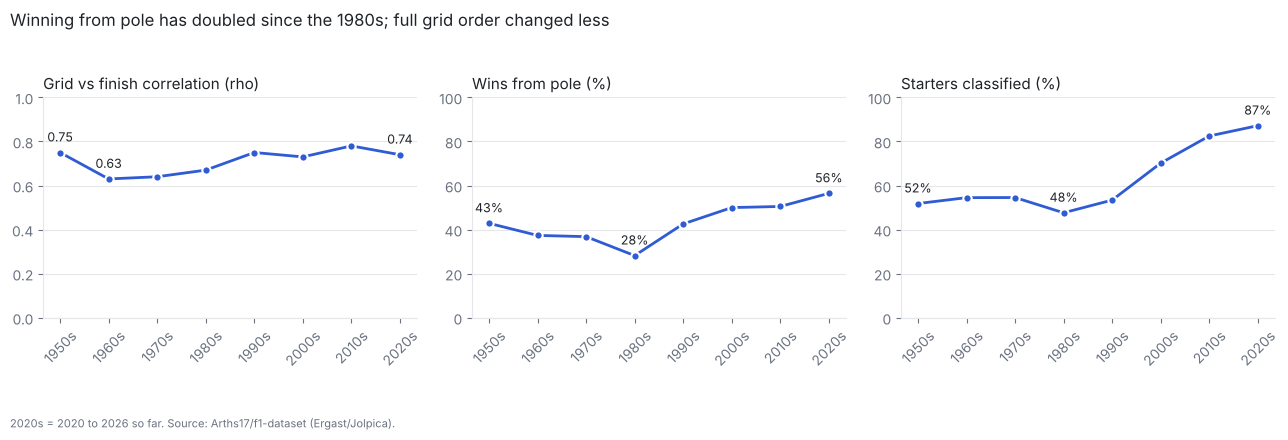

In [7]:
INK, MUTED, GRID, LINE = "#1f2328", "#6b7280", "#e5e7eb", "#2f5bd3"
plt.rcParams.update({"font.size": 10, "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
                     "xtick.color": MUTED, "ytick.color": MUTED})

panels = [
    ("grid_finish_rho",    "Grid vs finish correlation (rho)", "{:.2f}", 1),
    ("pct_wins_from_pole", "Wins from pole (%)",               "{:.0f}%", 100),
    ("pct_classified",     "Starters classified (%)",          "{:.0f}%", 100),
]
x = range(len(summary))
labels = [s.split()[0] for s in summary.index]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (col, title, fmt, top) in zip(axes, panels):
    y = summary[col].values
    ax.plot(x, y, color=LINE, lw=2, marker="o", ms=6, mec="white", mew=1.5)
    for i in {0, int(np.argmin(y)), len(y) - 1}:    # label first, lowest and last point only
        ax.annotate(fmt.format(y[i]), (i, y[i]), textcoords="offset points",
                    xytext=(0, 8), ha="center", color=INK, fontsize=9)
    ax.set_title(title, loc="left", color=INK, fontsize=11)
    ax.set_xticks(list(x), labels, rotation=45)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, top)   # zero baseline so changes are drawn to scale
fig.suptitle("Winning from pole has doubled since the 1980s; full grid order changed less",
             x=0.01, ha="left", color=INK, fontsize=12, y=1.04)
fig.text(0.01, -0.12, "2020s = 2020 to 2026 so far. Source: Arths17/f1-dataset (Ergast/Jolpica).",
         color=MUTED, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Robustness check: is it just reliability?

If more cars finishing explains the trend, then among races where most of the field finished, the correlation should be similar across decades.

In [8]:
finish_rate = starters.groupby("raceId")["classified"].mean().rename("finish_rate")
rho_rel = rho.merge(finish_rate, on="raceId")
high_finish = rho_rel[rho_rel["finish_rate"] >= 0.75]

check = pd.DataFrame({
    "races_75pct_finished": high_finish.groupby("decade")["raceId"].count(),
    "rho_when_75pct_finished": high_finish.groupby("decade")["rho"].mean().round(2),
    "rho_all_races": rho.groupby("decade")["rho"].mean().round(2),
})
check

,races_75pct_finished,rho_when_75pct_finished,rho_all_races
decade,,,
1950,2.0,0.64,0.75
1960,8.0,0.61,0.63
1970,5.0,0.69,0.64
1980,NaN,NaN,0.67
1990,9.0,0.83,0.75
2000,81.0,0.74,0.73
2010,162.0,0.78,0.78
2020,136.0,0.75,0.74


## 7. Reuse: overtaking by circuit (question 4 preview)

Same functions, different grouping. Lower rho means the race finished further from grid order, which suggests more overtaking or more chaos. Circuits need 10+ races to be included.

In [9]:
circuits = pd.read_csv(DATA / "circuits.csv", na_values=NA)
modern = rho[rho["year"] >= 2010]
by_circuit = (by_group(modern, "circuitId", "rho", min_n=10)
              .join(circuits.set_index("circuitId")["name"])
              .sort_values("value"))
print("Least grid-order finishes since 2010 (lowest rho):")
print(by_circuit.head(5)[["name", "n", "value"]].round(2).to_string())
print("\nMost processional since 2010 (highest rho):")
print(by_circuit.tail(5)[["name", "n", "value"]].round(2).to_string())

Least grid-order finishes since 2010 (lowest rho):
                                    name   n  value
circuitId                                          
18            Autódromo José Carlos Pace  15   0.71
13          Circuit de Spa-Francorchamps  17   0.72
3          Bahrain International Circuit  16   0.74
9                    Silverstone Circuit  18   0.74
73                     Baku City Circuit  10   0.74

Most processional since 2010 (highest rho):
                                     name   n  value
circuitId                                           
4          Circuit de Barcelona-Catalunya  17   0.81
17         Shanghai International Circuit  13   0.82
32           Autódromo Hermanos Rodríguez  10   0.82
22                         Suzuka Circuit  15   0.83
6                       Circuit de Monaco  16   0.84


## 8. Findings

**1. Starting on pole is worth far more now.** 28% of 1980s winners started from pole. In the 2020s so far it is 56%.

**2. The full grid order changed less.** The average grid-vs-finish correlation stays between 0.63 (1960s) and 0.78 (2010s) in every decade. Grid position has always been a strong predictor; the front of the field is where the change is concentrated.

**3. Races reshuffle less.** Finishers moved an average of 6.2 places in the 1980s and 2.9 in the 2020s.

**4. Reliability is the biggest shift.** 48% of starters were classified in the 1980s, 87% in the 2020s. Fewer breakdowns means less random reshuffling.

**5. Limitation: reliability and car performance can't be cleanly separated here.** Races where 75%+ of the field finished barely exist before 2000 (0 to 9 per decade), so the robustness check can only compare modern decades. Separating the effects would need car-performance data this dataset doesn't have.

**6. Circuits (preview of question 4).** Since 2010, Interlagos (0.71) and Spa (0.72) finish furthest from grid order, while Monaco (0.84) and Suzuka (0.83) are the most processional. The spread is small and each circuit has only 10 to 18 races, so treat this as a lead, not a result.

**Assumptions to state when presenting:** retirements are excluded from the correlation and counted in the reliability measure; eras are decades; the 2020s are partial (through the latest race in the data); the Indianapolis 500 and non-starters are excluded.